# Очередь M/M/c: десять клиентов
Базовый пример §7.2.4–7.2.5, стр. 214–215. Заявки поступают в общую FIFO-очередь.

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("MMCQueue.jl"))
using .MMCQueue
include(srcdir("experiment_support.jl"))

[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (2))


mean_interval (generic function with 1 method)

## Исходные параметры и события
Интенсивности: λ=.9, μ=.5; среднее обслуживание равно двум единицам времени.
Моменты прибытия генерируются до запуска календаря, как в примере практикума.

In [2]:
result = simulate_mmc(num_customers=10, num_servers=2, λ=.9, μ=.5, seed=123, verbose=true)
save_table("mmc_customers.csv", result.customers)
save_table("mmc_events.csv", result.events)
result.customers

Customer 1 arrived: 0.14518451436852475


Customer 1 entered service: 

0.14518451436852475
Customer 2 arrived: 0.5941831542903504
Customer 2 entered service: 0.5941831542903504
Customer 3 arrived: 1.5490648267819074
Customer 4 arrived: 1.6242796925312217
Customer 5 arrived: 1.6911000709069648
Customer 1 exited service: 2.200985520126681
Customer 3 entered service: 2.200985520126681
Customer 6 arrived: 2.2989039524296317
Customer 3 exited service: 3.5822120399442174
Customer 4 entered service: 3.5822120399442174
Customer 7 arrived: 4.377930221620457
Customer 8 arrived: 5.164942797008021
Customer 2 exited service: 5.900722829377648
Customer 5 entered service: 5.900722829377648
Customer 9 arrived: 7.0099944106308705
Customer 10 arrived: 7.828990220943469
Customer 5 exited service: 9.634196437885254
Customer 6 entered service: 9.634196437885254
Customer 4 exited service: 9.670688398447817
Customer 7 entered service: 9.670688398447817
Customer 7 exited service: 15.066978111608014
Customer 8 entered service: 15.066978111608014
Customer 8 exited service: 16.6555

Row,id,arrival,start,departure,wait,service,sojourn
,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,0.145185,0.145185,2.20099,0.0,2.0558,2.0558
2,2,0.594183,0.594183,5.90072,0.0,5.30654,5.30654
3,3,1.54906,2.20099,3.58221,0.651921,1.38123,2.03315
4,4,1.62428,3.58221,9.67069,1.95793,6.08848,8.04641
5,5,1.6911,5.90072,9.6342,4.20962,3.73347,7.9431
6,6,2.2989,9.6342,17.4018,7.33529,7.76764,15.1029
7,7,4.37793,9.67069,15.067,5.29276,5.39629,10.689
8,8,5.16494,15.067,16.6555,9.90204,1.58857,11.4906
9,9,7.00999,16.6555,17.5861,9.64555,0.930517,10.5761


## Наблюдаемые характеристики короткого прогона
Это запуск из пустого состояния, а не точная оценка стационарного режима.

In [3]:
observed = DataFrame([queue_summary(result)])
save_table("mmc_summary.csv", observed)
observed

Row,λ,μ,c,customers,warmup,observed,t0,t1,Wq,W,Lq,L,utilization,p_wait,mean_service,little_Lq_residual,little_L_residual
,Float64,Float64,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.9,0.5,2,10,0,10,0.0,7.82899,4.8568,8.41049,2.46311,4.36867,0.95278,0.8,3.5537,-1.90801,-3.20077


## Очередь и занятые каналы

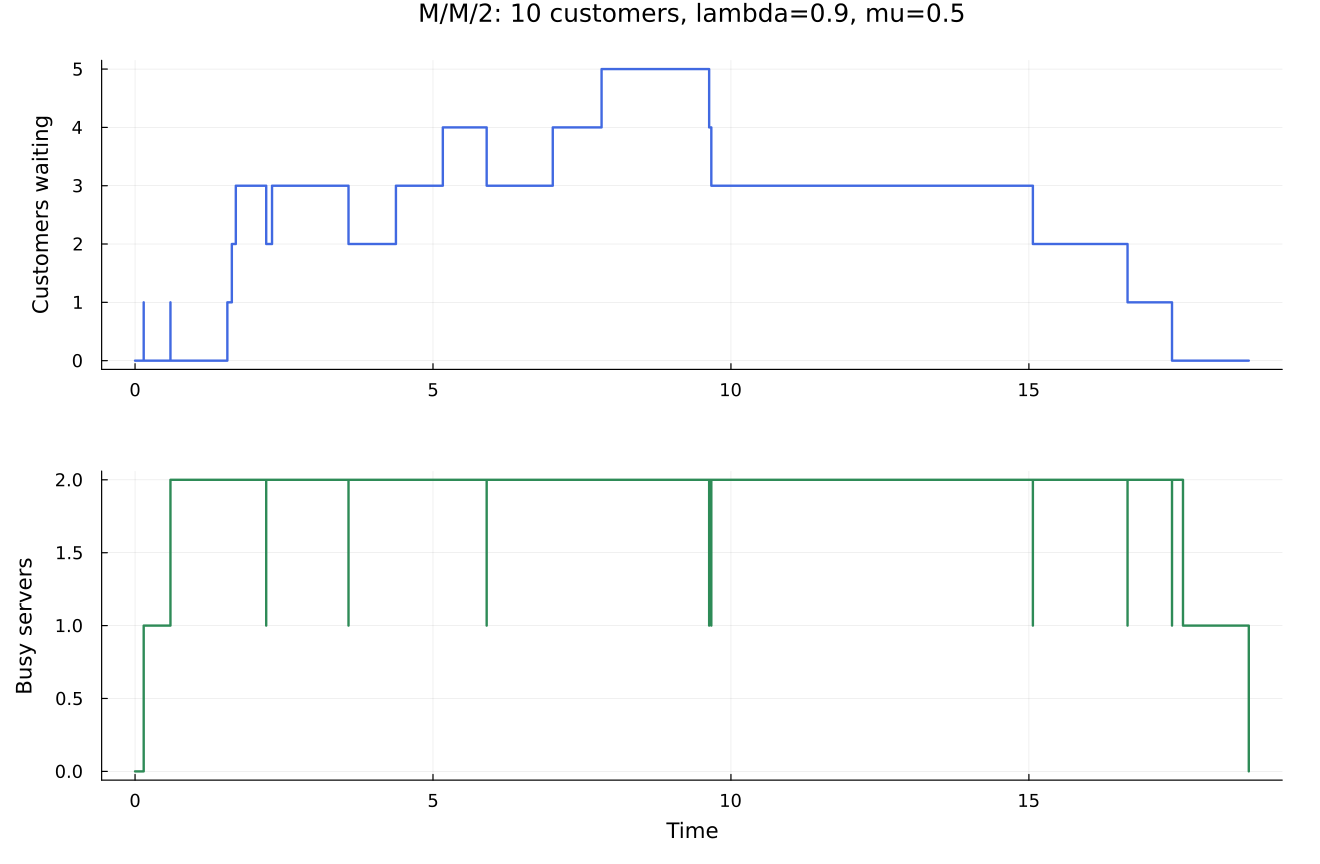

In [4]:
p_events = queue_plot(result.events; title="M/M/2: 10 customers, lambda=0.9, mu=0.5")
savefig(p_events, imagepath("01-plot.png"))
display(p_events)

## Время ожидания и обслуживания каждого клиента

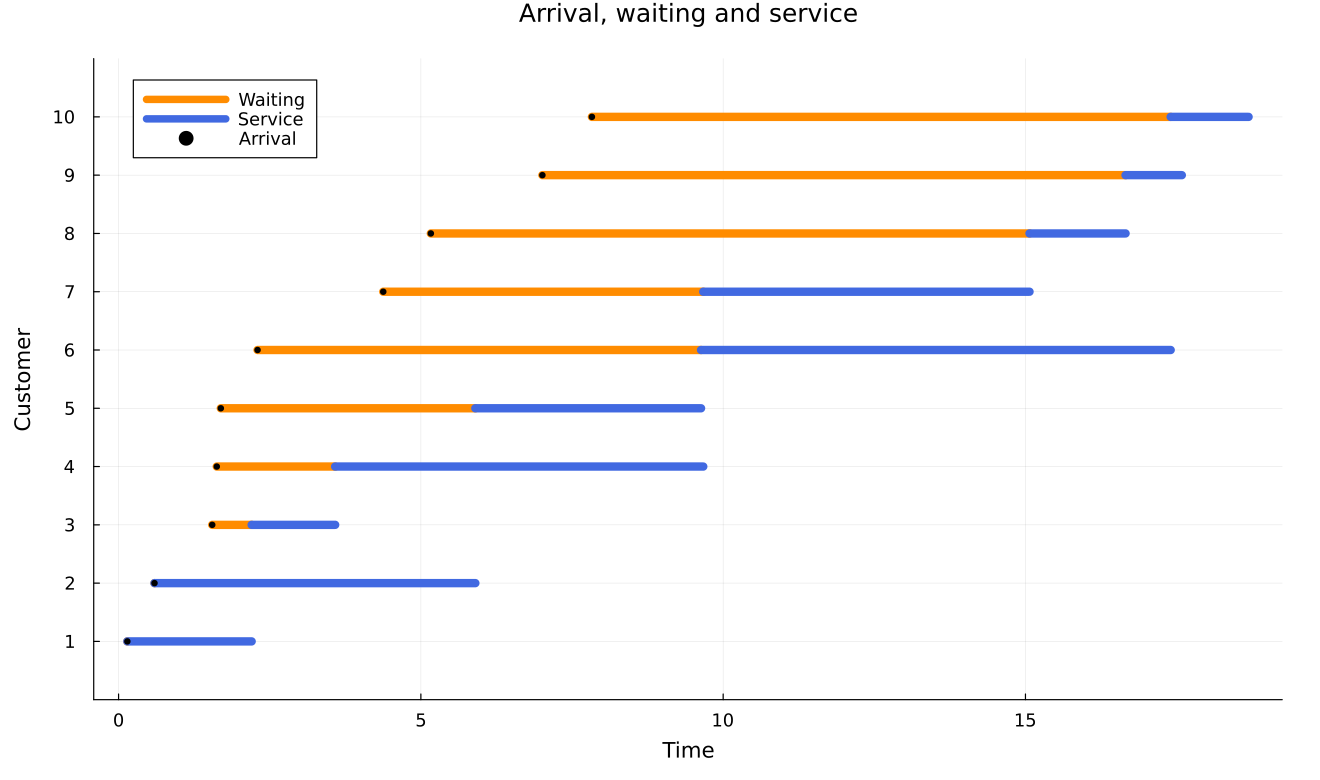

In [5]:
p_clients = customer_timeline(result.customers)
savefig(p_clients, imagepath("02-plot.png"))
display(p_clients)

## Аналитический ориентир
ρ=.9<1: стационарные формулы существуют. Для содержательного сравнения
используется длинная параметрическая серия, а не только эти десять клиентов.

In [6]:
theory = DataFrame([erlang_c(.9, .5, 2)])
save_table("mmc_theory.csv", theory)
theory

Row,rho,stable,p0,p_wait,Lq,Wq,W,L
,Float64,Bool,Float64,Float64,Float64,Float64,Float64,Float64
1,0.9,true,0.0526316,0.852632,7.67368,8.52632,10.5263,9.47368
